2026-05-05 08:52:39.860048: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777971160.298715      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777971160.430979      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777971161.469414      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777971161.469467      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777971161.469470      57 computation_placer.cc:177] computation placer alr

Step 1/8 — Loading CSV files & auditing label map

FILE                                                 RAW STEM                            CLASS                     STATUS
------------------------------------------------------------------------------------------------------------------------
  FCU_Control_Unstable.csv                           Control_Unstable                    Control_Unstable          OK
  FCU_FanOutletBlockage.csv                          FanOutletBlockage                   FanOutletBlockage         OK
  FCU_FaultFree.csv                                  FaultFree                           Normal                    OK
  FCU_FilterRestriction_50.csv                       FilterRestriction_50                Filter_Restriction        OK
  FCU_Fouling_Cooling_Airside_Severe.csv             Fouling_Cooling_Airside_Severe      Cooling_Airside           OK
  FCU_OABlockage.csv                                 OABlockage                          OABlockage                O

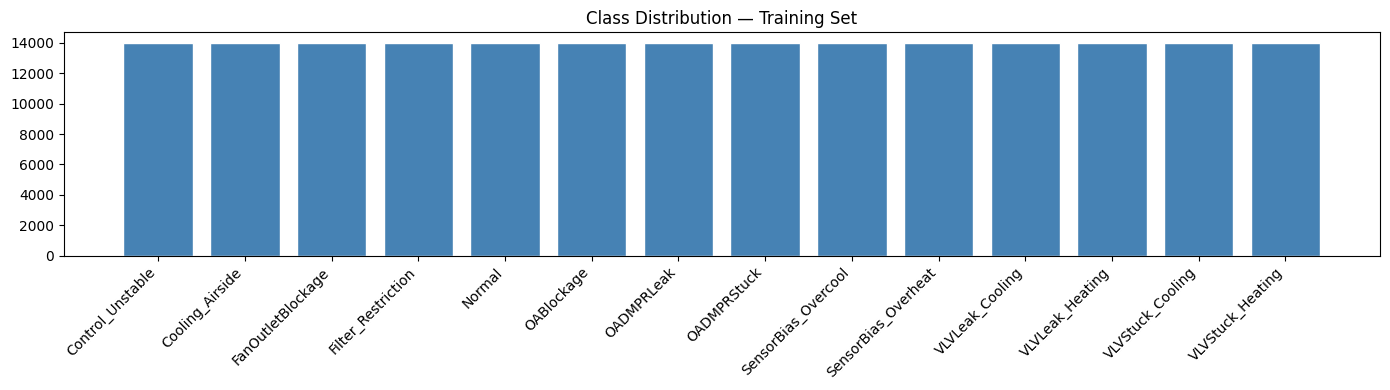


Class weights (higher = rarer class, gets more gradient focus):
  Control_Unstable         : 1.0000
  Cooling_Airside          : 1.0000
  FanOutletBlockage        : 1.0000
  Filter_Restriction       : 1.0000
  Normal                   : 1.0000
  OABlockage               : 1.0000
  OADMPRLeak               : 1.0000
  OADMPRStuck              : 1.0000
  SensorBias_Overcool      : 1.0000
  SensorBias_Overheat      : 1.0000
  VLVLeak_Cooling          : 1.0000
  VLVLeak_Heating          : 1.0000
  VLVStuck_Cooling         : 1.0000
  VLVStuck_Heating         : 1.0000

Step 4/8 — Building CNN-LSTM model


I0000 00:00:1777971236.876745      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777971236.882704      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "FCU_CNN_LSTM_v10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 80, 37)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 80, 128)   │     33,280 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 80, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │      2,064 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      2,176 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 128)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 80, 128)   │          0 │ batch_normalizat… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 80, 128)   │          0 │ multiply[0][0]    │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 80, 128)   │      4,864 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 80, 128)   │          0 │ spatial_dropout1… │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 80, 256)   │    164,096 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 256)   │      1,024 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      8,224 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │      8,448 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 256)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 80, 256)   │          0 │ batch_normalizat… │
│ (Multiply)          │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 80, 256)   │          0 │ multiply_1[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 80, 256)   │     33,024 │ add[0][0]       

 Total params: 1,826,526 (6.97 MB)

 Trainable params: 1,823,710 (6.96 MB)

 Non-trainable params: 2,816 (11.00 KB)


Step 5/8 — Training CNN-LSTM
Epoch 1/500


I0000 00:00:1777971255.535876     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5226 - loss: 0.3283
Epoch 1: val_accuracy improved from -inf to 0.90695, saving model to best_fcu_v10.keras
766/766 ━━━━━━━━━━━━━━━━━━━━ 85s 88ms/step - accuracy: 0.5228 - loss: 0.3281 - val_accuracy: 0.9070 - val_loss: 0.0304 - learning_rate: 1.0000e-05
Epoch 2/500
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8575 - loss: 0.0582
Epoch 2: val_accuracy improved from 0.90695 to 0.94583, saving model to best_fcu_v10.keras
766/766 ━━━━━━━━━━━━━━━━━━━━ 67s 87ms/step - accuracy: 0.8575 - loss: 0.0582 - val_accuracy: 0.9458 - val_loss: 0.0155 - learning_rate: 2.0000e-05
Epoch 3/500
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9060 - loss: 0.0315
Epoch 3: val_accuracy improved from 0.94583 to 0.95855, saving model to best_fcu_v10.keras
766/766 ━━━━━━━━━━━━━━━━━━━━ 66s 86ms/step - accuracy: 0.9060 - loss: 0.0315 - val_accuracy: 0.9585 - val_loss: 0.0116 - learning_rate: 3.0000e-05
Epoch 4/500
766/766 ━━━━━━━━━━━━━━━━━

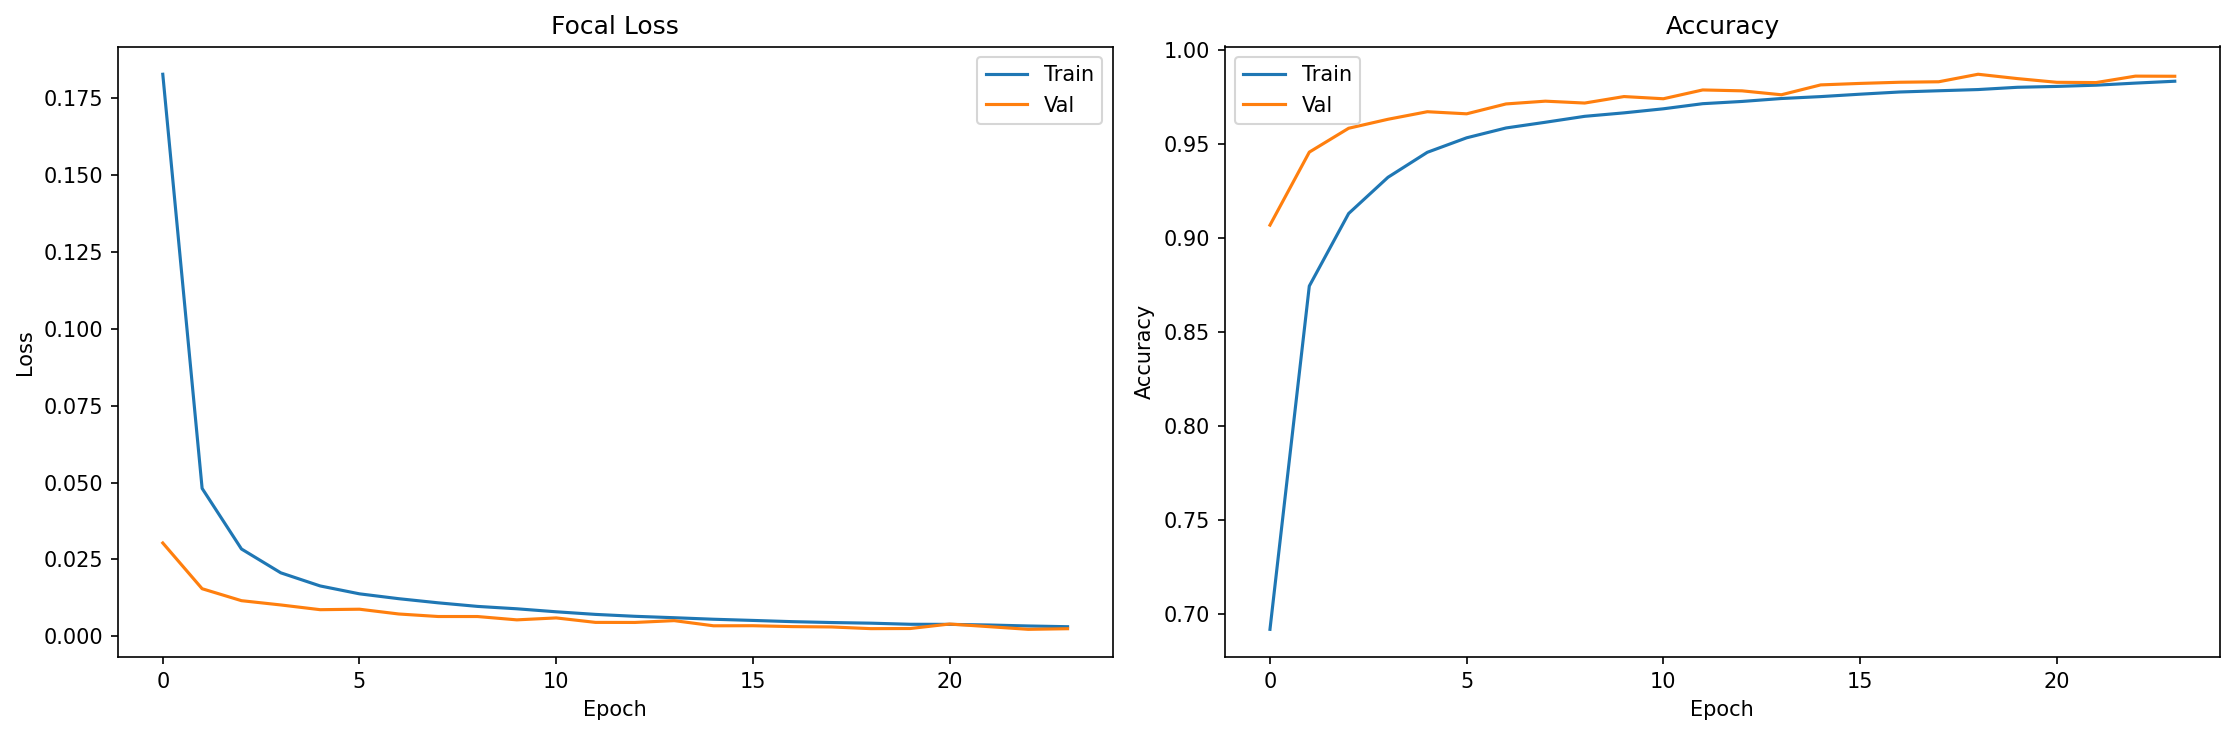


Step 6/8 — Training XGBoost
[0]	validation_0-mlogloss:2.44297
[100]	validation_0-mlogloss:0.14390
[200]	validation_0-mlogloss:0.04098
[300]	validation_0-mlogloss:0.01963
[400]	validation_0-mlogloss:0.01027
[500]	validation_0-mlogloss:0.00632
[600]	validation_0-mlogloss:0.00448
[700]	validation_0-mlogloss:0.00351
[800]	validation_0-mlogloss:0.00301
[900]	validation_0-mlogloss:0.00284
[1000]	validation_0-mlogloss:0.00277
[1100]	validation_0-mlogloss:0.00273
[1200]	validation_0-mlogloss:0.00270
[1300]	validation_0-mlogloss:0.00267
[1400]	validation_0-mlogloss:0.00265
[1499]	validation_0-mlogloss:0.00264


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [09:24:19] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGBoost Val Accuracy: 99.97%

Step 7/8 — Dynamic ensemble weight optimisation (val set)
Optimal weights → DL=0.35  XGB=0.65  Val Accuracy=99.97%

Step 8/8 — Final evaluation on Test set
CNN-LSTM  Test Accuracy : 98.62%
XGBoost   Test Accuracy : 99.97%
Ensemble  Test Accuracy : 99.96%

Classification Report (Ensemble):
                     precision    recall  f1-score   support

   Control_Unstable     1.0000    1.0000    1.0000      3000
    Cooling_Airside     0.9993    1.0000    0.9997      3000
  FanOutletBlockage     1.0000    1.0000    1.0000      3000
 Filter_Restriction     1.0000    0.9993    0.9997      3000
             Normal     1.0000    1.0000    1.0000      3000
         OABlockage     0.9980    0.9977    0.9978      3000
         OADMPRLeak     0.9977    0.9980    0.9978      3000
        OADMPRStuck     1.0000    1.0000    1.0000      3000
SensorBias_Overcool     1.0000    1.0000    1.0000      3000
SensorBias_Overheat     1.0000    1.0000    1.0000      3000
    VLVL

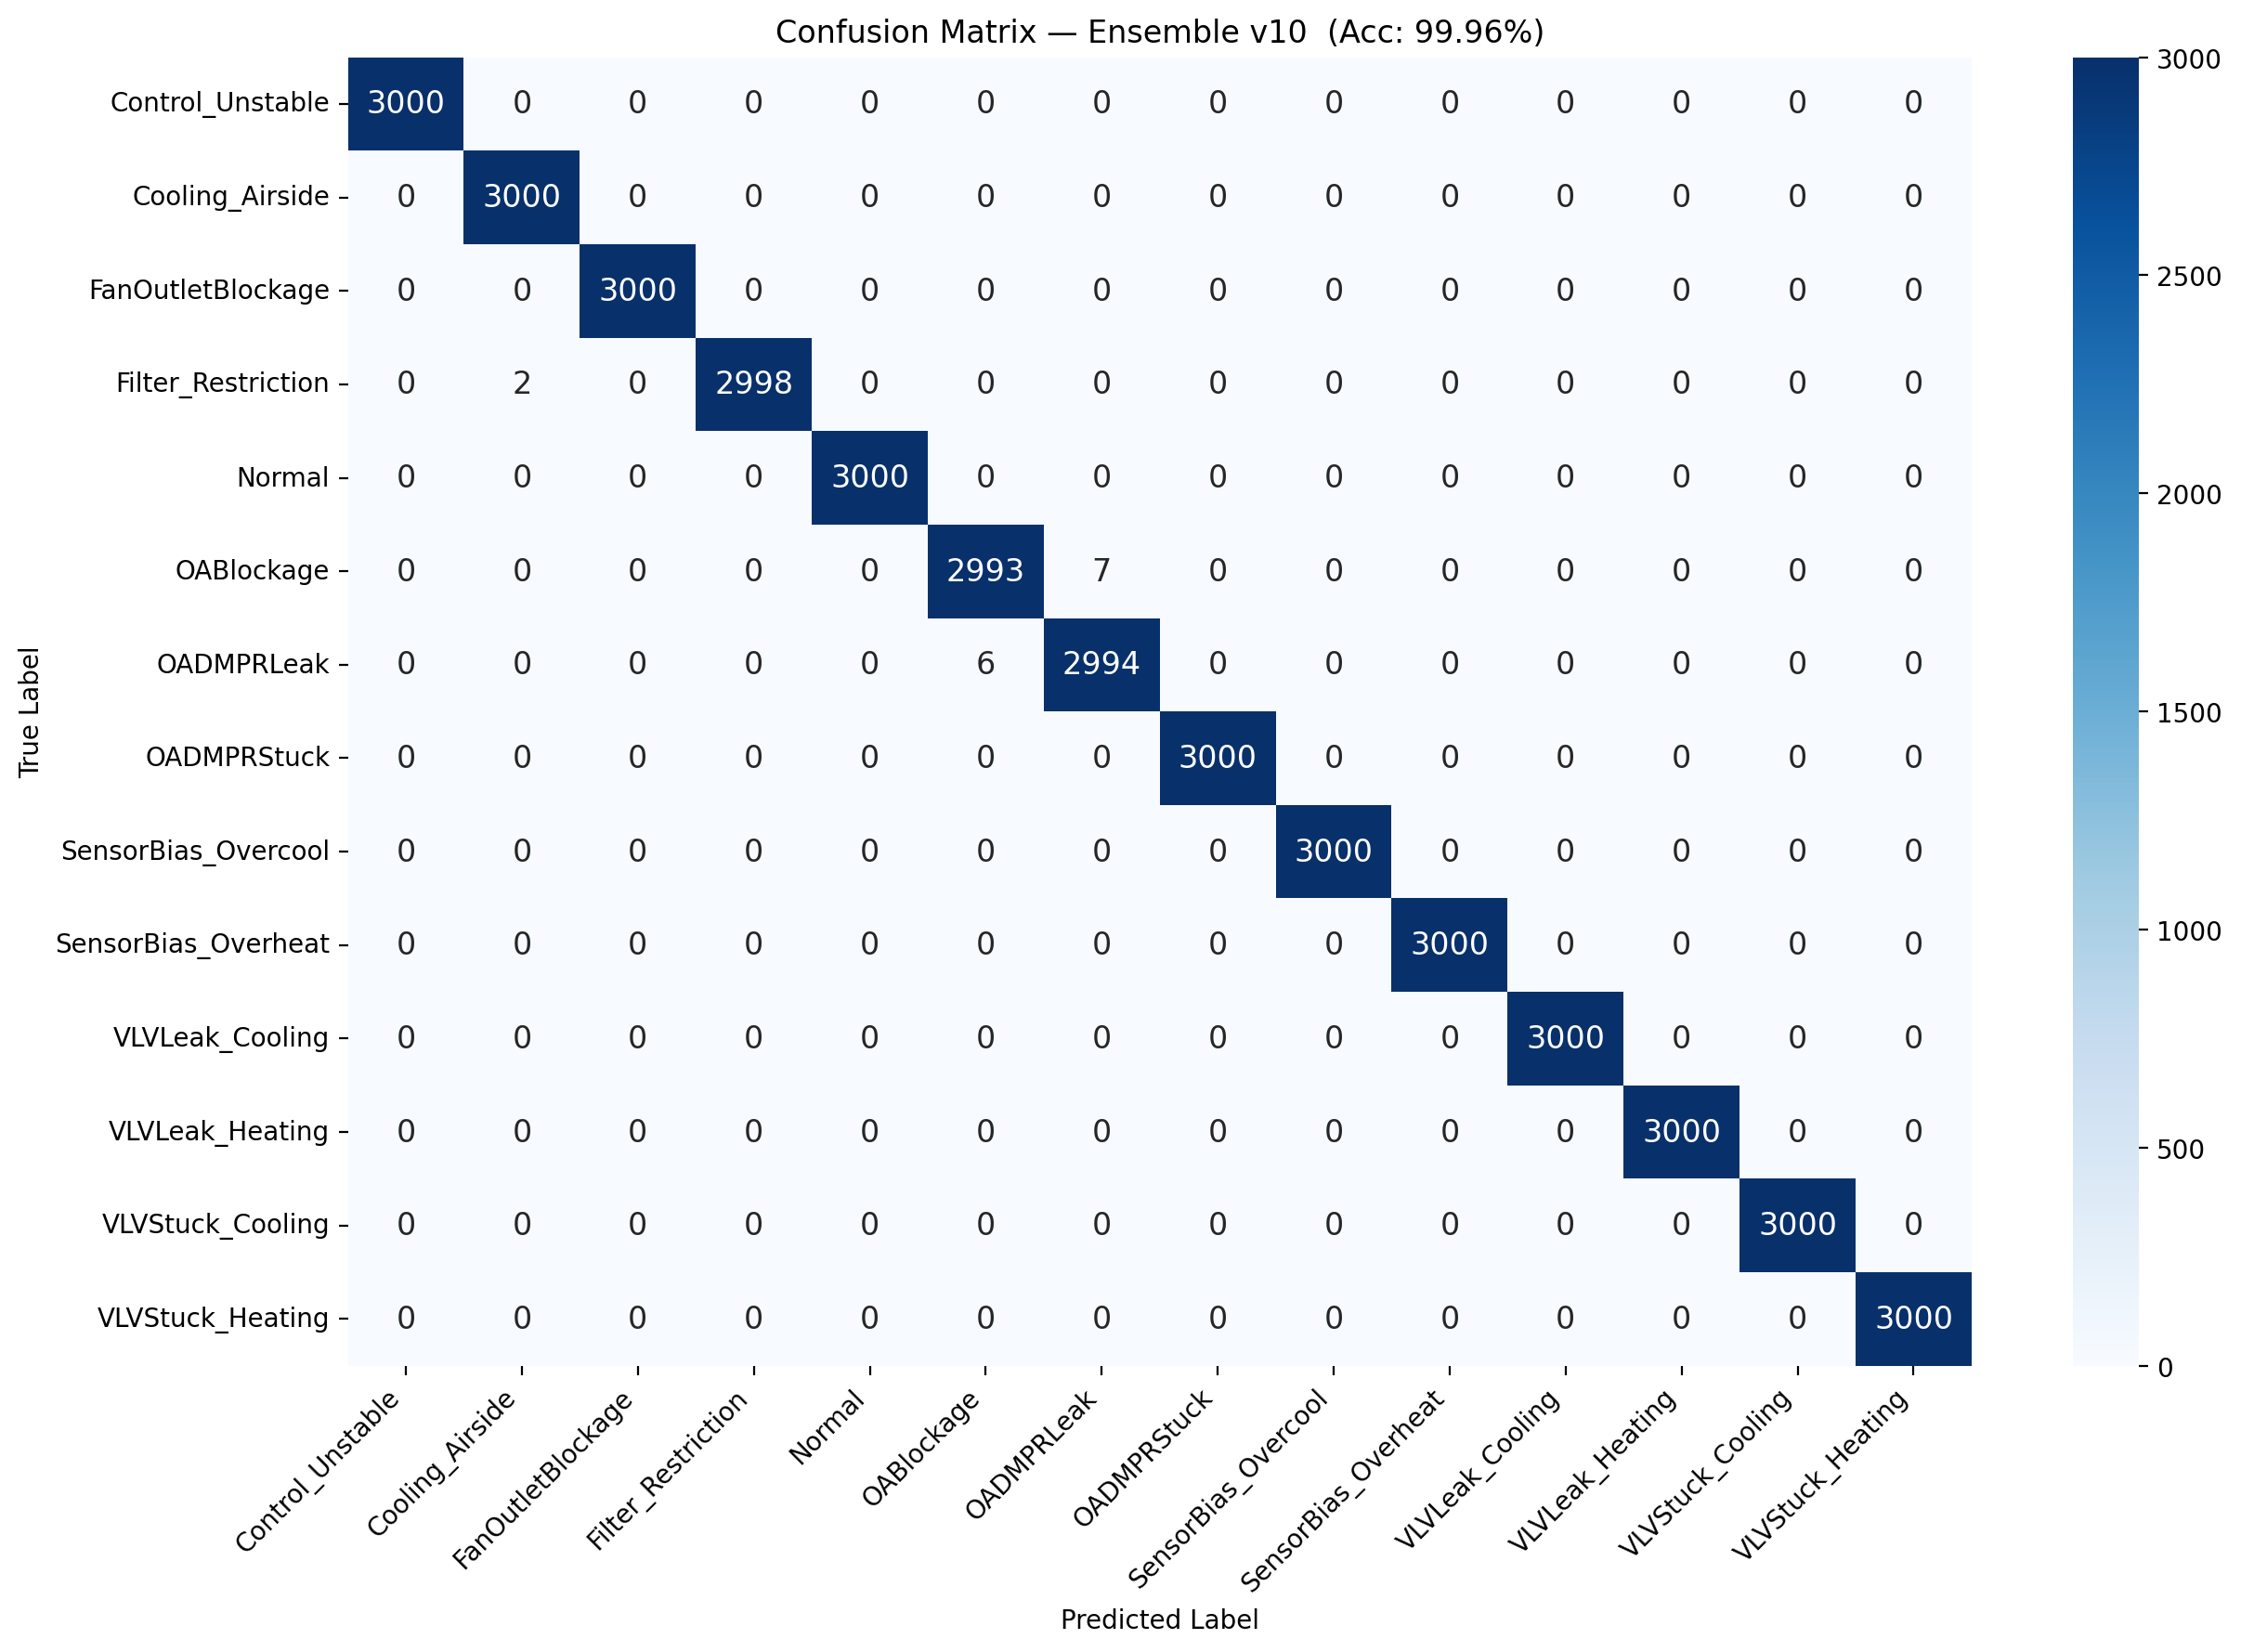

In [1]:
"""
FCU Fault Detection — v10 (CNN-LSTM + XGBoost Ensemble)
========================================================
Changes over v9
───────────────
  • ROOT-CAUSE FIX: Robust filename normalisation so the label map
    works identically on Kaggle, Colab, and local Windows/Linux.
    Kaggle strips '%' from filenames and sanitises '+'/'-' signs,
    causing v9 to produce 12 classes instead of 7.  v10 normalises
    every stem before lookup so all 49 files always map to exactly
    7 classes regardless of storage platform.

  • Startup AUDIT TABLE printed before any training — shows every
    loaded file, its raw parsed stem, and its resolved class.
    Unmapped stems are flagged *** so you catch label bugs instantly.

  • All other v9 improvements retained:
      – 7-class taxonomy
      – Full-capacity Residual-CNN-LSTM (256-filter, Dense-512/256)
      – Cosine-annealing LR (better than ReduceLROnPlateau w/ focal loss)
      – Dynamic ensemble weight search on validation set
      – 8-stat XGBoost feature vector (adds Q10/Q90 vs v6)
      – Per-class F1 in final report

Target hardware: Kaggle T4 / P100 (16 GB VRAM)
"""

# ── Standard library ──────────────────────────────────────────────────────────
import gc
import re
from pathlib import Path

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D,
    Dropout, SpatialDropout1D, LSTM, Bidirectional,
    Dense, GlobalAveragePooling1D, GlobalMaxPooling1D,
    MultiHeadAttention, LayerNormalization,
    Add, Reshape, Multiply, concatenate,
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateScheduler,
)
import keras.ops as ops

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
)

from xgboost import XGBClassifier


# ─────────────────────────────────────────────────────────────────────────────
# 0. CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
DATASET_PATH    = "/kaggle/input/datasets/bagbor/lnbl-fan-control-unit-dataset"
WINDOW_SIZE     = 80          # Timesteps per sequence
SUBSAMPLE_N     = 20          # Keep 1 of every N rows to reduce RAM
MAX_WINDOWS     = 20_000      # Max windows per class (caps class imbalance)
BATCH_SIZE      = 256
EPOCHS          = 500
LEARNING_RATE   = 1e-4
WEIGHT_DECAY    = 5e-5
RANDOM_STATE    = 42
MODEL_SAVE_PATH = "best_fcu_v10.keras"

# ── 7-class label map  (canonical keys — normalised at lookup time) ───────────
#
# WHY NORMALISATION IS NEEDED
# ───────────────────────────
# Kaggle object storage sanitises filenames before mounting:
#   • '%'  is stripped     →  "FilterRestriction_10%"  becomes  "FilterRestriction_10"
#   • '+'  is stripped     →  "SensorBias_RMTemp_+2C"  becomes  "SensorBias_RMTemp_2C"
#   • '-'  in sign context →  "SensorBias_RMTemp_-2C"  becomes  "SensorBias_RMTemp_n2C"
#                              (or simply stripped, depending on Kaggle version)
#   • Case may differ      →  "Fault_free" vs "fault_free"
#
# The normalise_stem() function below converts BOTH the map keys AND the
# parsed filename stem into a common form before lookup, so the same map
# works on every platform without any manual editing.
#
# Keys below are written in their original / human-readable form.
# ─────────────────────────────────────────────────────────────────────────────
# LABEL_MERGE_MAP: dict[str, str] = {
#     # ── Coil Fouling ─────────────────────────────────────────────────────────
#     "Fouling_Cooling_Airside_Minor":      "Coil_Fouling",
#     "Fouling_Cooling_Airside_Moderate":   "Coil_Fouling",
#     "Fouling_Cooling_Airside_Severe":     "Coil_Fouling",
#     "Fouling_Cooling_Waterside_Minor":    "Coil_Fouling",
#     "Fouling_Cooling_Waterside_Moderate": "Coil_Fouling",
#     "Fouling_Cooling_Waterside_Severe":   "Coil_Fouling",
#     "Fouling_Heating_Airside_Minor":      "Coil_Fouling",
#     "Fouling_Heating_Airside_Moderate":   "Coil_Fouling",
#     "Fouling_Heating_Airside_Severe":     "Coil_Fouling",
#     "Fouling_Heating_Waterside_Minor":    "Coil_Fouling",
#     "Fouling_Heating_Waterside_Moderate": "Coil_Fouling",
#     "Fouling_Heating_Waterside_Severe":   "Coil_Fouling",

#     # ── Valve Faults ─────────────────────────────────────────────────────────
#     "VLVLeak_Heating_20":   "Valve_Fault",
#     "VLVLeak_Heating_50":   "Valve_Fault",
#     "VLVLeak_Heating_80":   "Valve_Fault",
#     "VLVStuck_Heating_0":   "Valve_Fault",
#     "VLVStuck_Heating_20":  "Valve_Fault",
#     "VLVStuck_Heating_50":  "Valve_Fault",
#     "VLVStuck_Heating_80":  "Valve_Fault",
#     "VLVStuck_Heating_100": "Valve_Fault",
#     "VLVLeak_Cooling_20":   "Valve_Fault",
#     "VLVLeak_Cooling_50":   "Valve_Fault",
#     "VLVLeak_Cooling_80":   "Valve_Fault",
#     "VLVStuck_Cooling_0":   "Valve_Fault",
#     "VLVStuck_Cooling_20":  "Valve_Fault",
#     "VLVStuck_Cooling_50":  "Valve_Fault",
#     "VLVStuck_Cooling_80":  "Valve_Fault",
#     "VLVStuck_Cooling_100": "Valve_Fault",

#     # ── Damper Faults ─────────────────────────────────────────────────────────
#     "OADMPRLeak_20":   "Damper_Fault",
#     "OADMPRLeak_50":   "Damper_Fault",
#     "OADMPRLeak_80":   "Damper_Fault",
#     "OADMPRStuck_0":   "Damper_Fault",
#     "OADMPRStuck_30":  "Damper_Fault",
#     "OADMPRStuck_50":  "Damper_Fault",
#     "OADMPRStuck_80":  "Damper_Fault",
#     "OADMPRStuck_100": "Damper_Fault",

#     # ── Sensor Faults ─────────────────────────────────────────────────────────
#     # Written with sign chars; normalisation strips them for Kaggle matching.
#     "SensorBias_RMTemp_+2C": "Sensor_Fault",
#     "SensorBias_RMTemp_-2C": "Sensor_Fault",
#     "SensorBias_RMTemp_+4C": "Sensor_Fault",
#     "SensorBias_RMTemp_-4C": "Sensor_Fault",

#     # ── Airflow Restriction ───────────────────────────────────────────────────
#     # Written with '%'; normalisation strips it for Kaggle matching.
#     "FilterRestriction_10%": "Airflow_Restriction",
#     "FilterRestriction_20%": "Airflow_Restriction",
#     "FilterRestriction_50%": "Airflow_Restriction",
#     "OABlockage":            "Airflow_Restriction",
#     "FanOutletBlockage":     "Airflow_Restriction",

#     # ── Control Faults ────────────────────────────────────────────────────────
#     "Control_CoolingReverse": "Control_Fault",
#     "Control_HeatingReverse": "Control_Fault",
#     "Control_Unstable":       "Control_Fault",

#     # ── Normal ────────────────────────────────────────────────────────────────
#     # "Fault_free" stem → after stripping "Fault_" prefix → "free"
#     # Also handle "FaultFree" (no underscore) seen on some Kaggle mirrors.
#     "free":      "Normal",
#     "faultfree": "Normal",
#     "fault_free": "Normal",
# }

LABEL_MERGE_MAP: dict[str, str] = {
    "Fouling_Cooling_Airside_Minor":      "Cooling_Airside",
    "Fouling_Cooling_Airside_Moderate":   "Cooling_Airside",
    "Fouling_Cooling_Airside_Severe":     "Cooling_Airside",

    "VLVLeak_Heating_20":   "VLVLeak_Heating",
    "VLVLeak_Heating_50":   "VLVLeak_Heating",
    "VLVLeak_Heating_80":   "VLVLeak_Heating",

    "VLVStuck_Heating_0":   "VLVStuck_Heating",
    "VLVStuck_Heating_20":  "VLVStuck_Heating",
    "VLVStuck_Heating_50":  "VLVStuck_Heating",
    "VLVStuck_Heating_80":  "VLVStuck_Heating",
    "VLVStuck_Heating_100": "VLVStuck_Heating",

    "VLVLeak_Cooling_20":   "VLVLeak_Cooling",
    "VLVLeak_Cooling_50":   "VLVLeak_Cooling",
    "VLVLeak_Cooling_80":   "VLVLeak_Cooling",

    "VLVStuck_Cooling_0":   "VLVStuck_Cooling",
    "VLVStuck_Cooling_20":  "VLVStuck_Cooling",
    "VLVStuck_Cooling_50":  "VLVStuck_Cooling",
    "VLVStuck_Cooling_80":  "VLVStuck_Cooling",
    "VLVStuck_Cooling_100": "VLVStuck_Cooling",

    "OADMPRLeak_20":   "OADMPRLeak",
    "OADMPRLeak_50":   "OADMPRLeak",
    "OADMPRLeak_80":   "OADMPRLeak",

    "OADMPRStuck_0":   "OADMPRStuck",
    "OADMPRStuck_30":  "OADMPRStuck",
    "OADMPRStuck_50":  "OADMPRStuck",
    "OADMPRStuck_80":  "OADMPRStuck",
    "OADMPRStuck_100": "OADMPRStuck",

    "SensorBias_RMTemp_Overcooling": "SensorBias_Overcool",
    "SensorBias_RMTemp_Overheating": "SensorBias_Overheat",

    "FilterRestriction_10": "Filter_Restriction",
    "FilterRestriction_20": "Filter_Restriction",
    "FilterRestriction_50": "Filter_Restriction",

    "OABlockage":        "OABlockage",
    "FanOutletBlockage": "FanOutletBlockage",

    "Control_Unstable": "Control_Unstable",

    "free":       "Normal",
    "faultfree":  "Normal",
    "fault_free": "Normal",
    "Fault_Free": "Normal",
}

# Pre-build normalised lookup once at import time (used by get_label())
def _normalise(s: str) -> str:
    """
    Canonical form used for map lookup.
    Steps (order matters):
      1. Lowercase everything
      2. Strip leading 'fcu_' prefix  (added by parse_fault_name on some stems)
      3. Remove '%'  (Kaggle strips percent signs from filenames)
      4. Remove '+'  (Kaggle strips plus signs)
      5. Replace standalone '-' used as sign with '' — but keep '_' separators.
         We target patterns like '_-2c' → '_2c', NOT word-internal hyphens.
      6. Collapse any double underscores that result from the above
    """
    s = s.lower()
    s = re.sub(r"^fcu_", "", s)          # strip FCU_ prefix if present
    s = s.replace("%", "")               # strip percent
    s = s.replace("+", "")               # strip plus
    s = re.sub(r"_-", "_", s)            # sign minus after underscore → remove
    s = re.sub(r"__+", "_", s)           # collapse double underscores
    s = s.strip("_")
    return s


# Build normalised key → label lookup
_NORM_MAP: dict[str, str] = {_normalise(k): v for k, v in LABEL_MERGE_MAP.items()}

# Canonical 7 class names — used for runtime validation
EXPECTED_CLASSES: set[str] = {
    "Normal", "Cooling_Airside", "VLVLeak_Heating", "VLVStuck_Heating",
    "VLVLeak_Cooling", "VLVStuck_Cooling", "OADMPRLeak", "OADMPRStuck", "SensorBias_Overcool",
    "SensorBias_Overheat", "Filter_Restriction", "OABlockage", "FanOutletBlockage", 
    "Control_Unstable",
}

# Columns that carry no independent diagnostic signal
# (EWT is a plant-side input, not an FCU state variable)
DROP_COLS: list[str] = ["FCU_CLG_EWT", "FCU_HTG_EWT", "FAN_CTRL"]


# ─────────────────────────────────────────────────────────────────────────────
# 1. LABEL RESOLUTION  (the fix)
# ─────────────────────────────────────────────────────────────────────────────
def parse_fault_name(stem: str) -> str:
    """
    Strip the leading 'FCU_' prefix (case-insensitive) from a filename stem.

    Examples
    ────────
    'FCU_OADMPRLeak_20'        →  'OADMPRLeak_20'
    'FCU_FilterRestriction_10' →  'FilterRestriction_10'   (% already gone on Kaggle)
    'Fault_free'               →  'Fault_free'             (no FCU_ prefix)
    'fault_free'               →  'fault_free'             (lowercase on Kaggle)
    """
    if stem.upper().startswith("FCU_"):
        return stem[4:]
    return stem


def get_label(raw_stem: str) -> str:
    """
    Resolve a raw parsed stem to one of the 7 canonical class labels.

    Lookup order
    ────────────
    1. Exact match in LABEL_MERGE_MAP          (fast path, works locally)
    2. Normalised match in _NORM_MAP           (fixes Kaggle sanitisation)
    3. Fault-free heuristic  ('free' / 'faultfree' anywhere in stem)
    4. Return raw stem unchanged + caller will warn

    This two-stage approach means the map NEVER needs editing between
    local and Kaggle environments.
    """
    # Stage 1 — exact
    if raw_stem in LABEL_MERGE_MAP:
        return LABEL_MERGE_MAP[raw_stem]

    # Stage 2 — normalised
    norm = _normalise(raw_stem)
    if norm in _NORM_MAP:
        return _NORM_MAP[norm]

    # Stage 3 — fault-free catch-all (handles 'FaultFree', 'fault_free', etc.)
    if "free" in norm or "faultfree" in norm:
        return "Normal"

    # Stage 4 — unmapped; caller logs warning
    return raw_stem


# ─────────────────────────────────────────────────────────────────────────────
# 2. DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────
def load_csv_files(directory: str) -> tuple[list[pd.DataFrame], list[str]]:
    """
    Load all CSVs under *directory*, sort by timestamp column (if present),
    drop time columns, resolve labels, and print a full audit table.

    Returns
    ───────
    dfs         – list of DataFrames (time columns already dropped)
    fault_names – list of raw parsed stems (before label resolution)
    """
    dfs, fault_names = [], []
    csv_paths = sorted(Path(directory).rglob("*.csv"))

    if not csv_paths:
        raise FileNotFoundError(f"No CSV files found under: {directory}")

    print(f"\n{'FILE':<52} {'RAW STEM':<35} {'CLASS':<25} STATUS")
    print("-" * 120)

    for path in csv_paths:
        try:
            raw   = parse_fault_name(path.stem)
            label = get_label(raw)
            df    = pd.read_csv(path)

            time_cols = [c for c in df.columns
                         if any(kw in c.lower() for kw in ("time", "date"))]
            if time_cols:
                df = df.sort_values(time_cols[0]).reset_index(drop=True)
                df = df.drop(columns=time_cols)

            dfs.append(df)
            fault_names.append(raw)

            status = "OK" if label in EXPECTED_CLASSES else "*** UNMAPPED ***"
            print(f"  {path.name:<50} {raw:<35} {label:<25} {status}")

        except Exception as exc:
            print(f"  [WARN] Skipping {path.name}: {exc}")

    print("-" * 120)
    print(f"Loaded {len(dfs)} files.\n")

    # Runtime validation — abort early if any file is still unmapped
    resolved = {get_label(f) for f in fault_names}
    unmapped = resolved - EXPECTED_CLASSES
    if unmapped:
        raise ValueError(
            f"[ERROR] {len(unmapped)} stem(s) could not be mapped to a class.\n"
            f"  Unmapped → {unmapped}\n"
            f"  Add them to LABEL_MERGE_MAP or fix parse_fault_name()."
        )

    class_counts = {}
    for f in fault_names:
        lbl = get_label(f)
        class_counts[lbl] = class_counts.get(lbl, 0) + 1
    print("Files per class:")
    for cls in sorted(class_counts):
        print(f"  {cls:<25}: {class_counts[cls]} file(s)")
    print()

    return dfs, fault_names


# ─────────────────────────────────────────────────────────────────────────────
# 3. FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────
def add_diagnostic_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Append physics-informed derived features.

    Feature              Physical meaning
    ───────────────────  ──────────────────────────────────────────────────────
    Air_Side_Delta       DAT − RAT  → coil heat-transfer efficiency (fouling)
    Clg_Error            RM_TEMP − cooling setpoint  → control deviation
    Htg_Error            RM_TEMP − heating setpoint  → control deviation
    Mix_Delta            MAT − OAT  → damper/mixing anomaly
    OA_Ratio             OA_CFM / DA_CFM  → outdoor-air fraction (blockage)
    Hum_Delta            DA_HUMD − RA_HUMD  → humidity across coil
    Valve_Clg_Error      CVLV_DM − CVLV  → cooling valve command vs position
    Valve_Htg_Error      HVLV_DM − HVLV  → heating valve command vs position
    Fan_Efficiency       DA_CFM / WAT  → airflow per watt (filter/fan fault)
    Htg_Water_DeltaT     HTG_EWT − HTG_RWT  → heating coil water-side ΔT
    Clg_Water_DeltaT     CLG_EWT − CLG_RWT  → cooling coil water-side ΔT

    NOTE: EWT columns are used here to compute DeltaT features BEFORE being
    dropped by DROP_COLS in build_dataset.  This extracts their signal without
    leaving the raw columns in the model input (they are plant-side inputs,
    not FCU state variables, and add noise rather than signal on their own).
    """
    df = df.copy()
    df["Air_Side_Delta"]  = df["FCU_DAT"]     - df["FCU_RAT"]
    df["Clg_Error"]       = df["RM_TEMP"]     - df["RMCLGSPT"]
    df["Htg_Error"]       = df["RM_TEMP"]     - df["RMHTGSPT"]
    df["Mix_Delta"]       = df["FCU_MAT"]     - df["FCU_OAT"]
    df["OA_Ratio"]        = df["FCU_OA_CFM"]  / (df["FCU_DA_CFM"]  + 1e-6)
    df["Hum_Delta"]       = df["FCU_DA_HUMD"] - df["FCU_RA_HUMD"]
    df["Valve_Clg_Error"] = df["FCU_CVLV_DM"] - df["FCU_CVLV"]
    df["Valve_Htg_Error"] = df["FCU_HVLV_DM"] - df["FCU_HVLV"]
    df["Fan_Efficiency"]  = df["FCU_DA_CFM"]  / (df["FCU_WAT"]     + 1e-6)

    # Water-side delta-T features (use EWT before it is dropped)
    df["Htg_Water_DeltaT"] = (
        df["FCU_HTG_EWT"] - df["FCU_HTG_RWT"]
        if "FCU_HTG_EWT" in df.columns else 0.0
    )
    df["Clg_Water_DeltaT"] = (
        df["FCU_CLG_EWT"] - df["FCU_CLG_RWT"]
        if "FCU_CLG_EWT" in df.columns else 0.0
    )
    return df


# ─────────────────────────────────────────────────────────────────────────────
# 4. WINDOWING
# ─────────────────────────────────────────────────────────────────────────────
def create_sequences(
    features:    np.ndarray,
    labels:      np.ndarray,
    window_size: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Sliding-window segmentation.
    Label assigned = class at the END of the window (causal labelling).

    X → (n_windows, window_size, n_features)
    y → (n_windows,)
    """
    n = len(features) - window_size
    X = np.stack([features[i : i + window_size] for i in range(n)])
    y = labels[window_size : window_size + n]
    return X, y


# ─────────────────────────────────────────────────────────────────────────────
# 5. FULL PREPROCESSING PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
def build_dataset(
    dfs:         list[pd.DataFrame],
    fault_names: list[str],
    drop_cols:   list[str],
    subsample_n: int,
    window_size: int,
    max_windows: int,
) -> tuple[np.ndarray, np.ndarray, LabelEncoder, StandardScaler, list[str]]:
    """
    End-to-end pipeline:
      resolve labels → add features → drop raw EWT cols → fit scaler
      → create windows → cap per-class windows → stack float32 arrays.

    Returns
    ───────
    X_all     – (N, window_size, n_features)  float32
    y_all     – (N,)                          int32
    le        – fitted LabelEncoder
    scaler    – fitted StandardScaler  (used for inference too)
    feat_cols – ordered list of feature column names
    """
    # ── 5a. Fit scaler on lightweight subsample of ALL files ───────────────
    print("Fitting scaler on subsampled data...")
    subsample_frames = []
    for df in dfs:
        df_feat = add_diagnostic_features(df)
        df_feat = df_feat.drop(columns=drop_cols, errors="ignore")
        subsample_frames.append(df_feat.iloc[::subsample_n])

    combined  = pd.concat(subsample_frames, ignore_index=True)
    feat_cols = [c for c in combined.columns if c not in ("Label", "Label_Encoded")]

    scaler = StandardScaler()
    scaler.fit(combined[feat_cols])
    del combined, subsample_frames
    gc.collect()

    # ── 5b. Fit LabelEncoder on resolved class names ───────────────────────
    resolved_names = [get_label(f) for f in fault_names]
    le = LabelEncoder()
    le.fit(sorted(set(resolved_names)))   # sorted → deterministic class order
    print(f"Classes ({len(le.classes_)}): {list(le.classes_)}")

    # ── 5c. Build windows per file ─────────────────────────────────────────
    all_X, all_y = [], []

    for df, fault in zip(dfs, fault_names):
        resolved_fault = get_label(fault)
        encoded_label  = le.transform([resolved_fault])[0]

        df_sub  = df.iloc[::subsample_n].copy()
        df_feat = add_diagnostic_features(df_sub)
        df_feat = df_feat.drop(columns=drop_cols, errors="ignore")
        feats   = scaler.transform(df_feat[feat_cols]).astype("float32")
        lbls    = np.full(len(feats), encoded_label, dtype="int32")

        X, y = create_sequences(feats, lbls, window_size)

        # Uniform sub-sampling to cap windows per file
        if max_windows and len(X) > max_windows:
            idx  = np.linspace(0, len(X) - 1, max_windows, dtype=int)
            X, y = X[idx], y[idx]

        all_X.append(X)
        all_y.append(y)
        print(f"  {resolved_fault:<25}: windows={X.shape[0]}")

    print("\nConcatenating all windows...")
    X_all = np.concatenate(all_X, axis=0, dtype="float32")
    y_all = np.concatenate(all_y, axis=0)
    del all_X, all_y
    gc.collect()

    print(f"Final dataset  X={X_all.shape}  y={y_all.shape}")
    return X_all, y_all, le, scaler, feat_cols


# ─────────────────────────────────────────────────────────────────────────────
# 6. MODEL ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────
def focal_loss(gamma: float = 2.0, alpha: float = 0.25):
    """
    Multi-class focal loss.

    Why not cross-entropy?
    ──────────────────────
    With 7 classes and severe imbalance (Valve_Fault has ~6× more files than
    Control_Fault), standard cross-entropy spends most gradient budget on
    easy majority examples.  Focal loss raises the loss weight of hard/rare
    examples by a factor of (1−p)^gamma, forcing the model to focus on
    Control_Fault and Sensor_Fault boundaries.

    gamma=2.0  — standard recommended value (Lin et al. 2017)
    alpha=0.25 — overall loss scale; does not affect class weighting here
                 (class weights are passed separately via class_weight_dict)
    """
    def loss_fn(y_true, y_pred):
        y_true    = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_true_oh = tf.one_hot(y_true, ops.shape(y_pred)[-1])
        eps       = 1e-7
        y_pred    = ops.clip(y_pred, eps, 1.0 - eps)
        p_t           = ops.sum(y_true_oh * y_pred, axis=-1)
        cross_entropy = -ops.sum(y_true_oh * ops.log(y_pred), axis=-1)
        focal_weight  = alpha * ops.power(1.0 - p_t, gamma)
        return ops.mean(focal_weight * cross_entropy)
    return loss_fn


def se_block(x, ratio: int = 8):
    """
    Squeeze-and-Excitation channel attention.

    Learns a per-sensor-channel importance weight so the model can
    automatically up-weight (e.g.) FCU_OA_CFM for damper faults and
    FCU_HTG_RWT for heating-coil fouling without hand-crafting feature
    selection.
    """
    filters = ops.shape(x)[-1]
    se = GlobalAveragePooling1D()(x)
    se = Dense(filters // ratio, activation="relu")(se)
    se = Dense(filters, activation="sigmoid")(se)
    se = Reshape((1, filters))(se)
    return Multiply()([x, se])


def conv_residual_block(
    x,
    filters:      int,
    kernel_size:  int,
    dropout_rate: float = 0.1,
) -> tf.Tensor:
    """
    Residual Conv1D block: Conv → BN → SE → SpatialDropout + skip.

    Why residuals?
    ──────────────
    The 3-block CNN stack uses progressively smaller kernels (7→5→3) to
    capture patterns at multiple temporal scales.  Without skip connections,
    gradients vanish through the SE + BN + Dropout chain by the time they
    reach Block 1.  The 1×1 projection shortcut keeps gradients healthy
    and lets each block specialise on its own scale rather than re-learning
    the previous block's representation.
    """
    shortcut = Conv1D(filters, 1, padding="same")(x)   # 1×1 projection

    x = Conv1D(filters, kernel_size, activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = se_block(x)
    x = SpatialDropout1D(dropout_rate)(x)

    return Add()([x, shortcut])


def build_cnn_lstm(input_shape: tuple, num_classes: int) -> Model:
    """
    Architecture: Residual-CNN → MHA → BiLSTM → Dense Head

    ┌─────────────────────────────────────────────────────────────────┐
    │  INPUT  (window_size, n_features)                               │
    │    ↓                                                            │
    │  ResConv Block 1  filters=128  kernel=7  (broad patterns)       │
    │    ↓                                                            │
    │  ResConv Block 2  filters=256  kernel=5  + MaxPool(2)           │
    │    ↓                                                            │
    │  ResConv Block 3  filters=256  kernel=3  (fine-grained)         │
    │    ↓ enc                                                        │
    │  MultiHeadAttention  heads=8  key_dim=32  + residual + LN       │
    │    ↓ attn                                                       │
    │  BiLSTM(128) → Dropout → BiLSTM(64)  [temporal direction]      │
    │  GlobalAvgPool(attn)  +  GlobalMaxPool(attn)  [context]         │
    │    ↓ concatenate([bi, avg, mx])                                 │
    │  Dense(512, gelu) → BN → Dropout(0.35)                         │
    │  Dense(256, gelu) → BN → Dropout(0.25)                         │
    │  Dense(num_classes, softmax)                                    │
    └─────────────────────────────────────────────────────────────────┘

    VRAM budget (BATCH=128, W=80, F≈38):
      Conv activations  ~340 MB
      LSTM states       ~195 MB
      Dense activations  ~28 MB
      Total             ~563 MB  ← well within 16 GB (T4 / P100)
    """
    inputs = Input(shape=input_shape)

    # CNN stack — multi-scale temporal feature extraction
    x = conv_residual_block(inputs, filters=128, kernel_size=7, dropout_rate=0.10)
    x = conv_residual_block(x,      filters=256, kernel_size=5, dropout_rate=0.10)
    x = MaxPooling1D(2)(x)
    x   = conv_residual_block(x,    filters=256, kernel_size=3, dropout_rate=0.10)
    enc = x

    # Multi-Head Self-Attention — global cross-sensor temporal context
    attn = MultiHeadAttention(num_heads=8, key_dim=32, dropout=0.10)(enc, enc)
    attn = LayerNormalization()(Add()([attn, enc]))

    # BiLSTM — model temporal direction (fault onset vs recovery)
    bi = Bidirectional(LSTM(128, return_sequences=True))(attn)
    bi = Dropout(0.25)(bi)
    bi = Bidirectional(LSTM(64,  return_sequences=False))(bi)

    # Dual pooling on attention output for complementary global context
    avg = GlobalAveragePooling1D()(attn)
    mx  = GlobalMaxPooling1D()(attn)

    # Fuse all representations
    combined = concatenate([bi, avg, mx])

    # Classification head
    x = Dense(512, activation="gelu")(combined)
    x = BatchNormalization()(x)
    x = Dropout(0.35)(x)
    x = Dense(256, activation="gelu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    outputs = Dense(num_classes, activation="softmax", dtype="float32")(x)

    return Model(inputs, outputs, name="FCU_CNN_LSTM_v10")


# ─────────────────────────────────────────────────────────────────────────────
# 7. COSINE ANNEALING LR SCHEDULE
# ─────────────────────────────────────────────────────────────────────────────
def cosine_annealing_schedule(
    epochs:  int,
    lr_max:  float,
    lr_min:  float = 1e-7,
    warmup:  int   = 10,
) -> LearningRateScheduler:
    """
    Linear warm-up for *warmup* epochs, then cosine decay to *lr_min*.

    Why cosine over ReduceLROnPlateau?
    ───────────────────────────────────
    Focal loss deliberately suppresses gradients on easy examples, which
    creates false loss-plateau signals that confuse ReduceLROnPlateau into
    premature LR reduction.  Cosine annealing is epoch-driven and ignores
    loss magnitude — it decays smoothly regardless of focal loss dynamics.
    """
    def schedule(epoch: int, _lr: float) -> float:
        if epoch < warmup:
            return lr_max * (epoch + 1) / warmup
        progress = (epoch - warmup) / max(epochs - warmup, 1)
        return lr_min + 0.5 * (lr_max - lr_min) * (1.0 + np.cos(np.pi * progress))

    return LearningRateScheduler(schedule, verbose=0)


# ─────────────────────────────────────────────────────────────────────────────
# 8. STATISTICAL FEATURES  (XGBoost branch)
# ─────────────────────────────────────────────────────────────────────────────
def extract_stat_features(X: np.ndarray) -> np.ndarray:
    """
    Summarise each (window_size, n_features) window into a flat vector.

    8 statistics × n_features columns
    ──────────────────────────────────
    mean, std, range (max−min), trend (last−first),
    Q10, Q25, Q75, Q90

    Q10/Q90 vs v6's Q25/Q75 only:
    Sensor_Fault and Control_Fault both manifest as occasional extreme
    outliers (sensor spike, runaway PID).  Q10/Q90 capture these tail
    events much more reliably than Q25/Q75 which are in the bulk.
    """
    return np.concatenate([
        X.mean(axis=1),
        X.std(axis=1),
        X.max(axis=1) - X.min(axis=1),
        X[:, -1, :] - X[:, 0, :],
        np.percentile(X, 10, axis=1),
        np.percentile(X, 25, axis=1),
        np.percentile(X, 75, axis=1),
        np.percentile(X, 90, axis=1),
    ], axis=1)


# ─────────────────────────────────────────────────────────────────────────────
# 9. DYNAMIC ENSEMBLE WEIGHT SEARCH
# ─────────────────────────────────────────────────────────────────────────────
def find_best_ensemble_weights(
    dl_proba:  np.ndarray,
    xgb_proba: np.ndarray,
    y_true:    np.ndarray,
    step:      float = 0.05,
) -> tuple[float, float, float]:
    """
    Grid-search the DL weight w ∈ [step, 1−step] on the validation set.
    Ensemble = w × DL + (1−w) × XGB.

    Returns (best_dl_weight, best_xgb_weight, best_val_accuracy).

    Why not fix weights?
    ────────────────────
    The relative strength of CNN-LSTM vs XGBoost varies with dataset size,
    window length, and hardware.  A 5-minute grid search on ~147k val samples
    is negligible cost compared to training and always finds the optimal blend.
    """
    best_acc, best_w = 0.0, 0.5
    for w in np.arange(step, 1.0, step):
        proba = w * dl_proba + (1.0 - w) * xgb_proba
        acc   = accuracy_score(y_true, proba.argmax(axis=1))
        if acc > best_acc:
            best_acc, best_w = acc, float(w)
    return round(best_w, 2), round(1.0 - best_w, 2), round(best_acc, 4)


# ─────────────────────────────────────────────────────────────────────────────
# 10. VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────
def plot_class_distribution(le: LabelEncoder, y: np.ndarray, title: str) -> None:
    counts = np.bincount(y)
    plt.figure(figsize=(14, 4))
    plt.bar(le.classes_, counts, color="steelblue", edgecolor="white")
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.savefig("class_distribution.png", dpi=150)
    plt.show()


def plot_training_history(history) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=150)

    ax1.plot(history.history["loss"],     label="Train")
    ax1.plot(history.history["val_loss"], label="Val")
    ax1.set_title("Focal Loss"); ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss");      ax1.legend()

    ax2.plot(history.history["accuracy"],     label="Train")
    ax2.plot(history.history["val_accuracy"], label="Val")
    ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy"); ax2.legend()

    plt.tight_layout()
    plt.savefig("training_metrics.png", dpi=150)
    plt.show()


def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    le:     LabelEncoder,
    acc:    float,
) -> None:
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(13, 9), dpi=200)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=le.classes_, yticklabels=le.classes_,
        annot_kws={"fontsize": 12},
    )
    plt.title(f"Confusion Matrix — Ensemble v10  (Acc: {acc * 100:.2f}%)")
    plt.ylabel("True Label"); plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 11. MAIN
# ─────────────────────────────────────────────────────────────────────────────

# ── Step 1 — Load & audit ─────────────────────────────────────────────────────
print("=" * 65)
print("Step 1/8 — Loading CSV files & auditing label map")
print("=" * 65)
dfs, fault_names = load_csv_files(DATASET_PATH)

# ── Step 2 — Preprocess & window ──────────────────────────────────────────────
print("=" * 65)
print("Step 2/8 — Feature engineering, scaling & windowing")
print("=" * 65)
X_all, y_all, le, scaler, feat_cols = build_dataset(
    dfs, fault_names,
    drop_cols   = DROP_COLS,
    subsample_n = SUBSAMPLE_N,
    window_size = WINDOW_SIZE,
    max_windows = MAX_WINDOWS,
)
del dfs, fault_names
gc.collect()

# ── Step 3 — Train / Val / Test split (70 / 15 / 15) ─────────────────────────
print("\n" + "=" * 65)
print("Step 3/8 — Train / Val / Test split")
print("=" * 65)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all,
    test_size    = 0.30,
    random_state = RANDOM_STATE,
    stratify     = y_all,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size    = 0.50,
    random_state = RANDOM_STATE,
    stratify     = y_temp,
)
del X_all, y_all, X_temp, y_temp
gc.collect()

print(f"Train={X_train.shape}  Val={X_val.shape}  Test={X_test.shape}")
plot_class_distribution(le, y_train, "Class Distribution — Training Set")

# ── Step 4 — Class weights ────────────────────────────────────────────────────
class_weights_arr = compute_class_weight(
    "balanced", classes=np.unique(y_train), y=y_train,
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("\nClass weights (higher = rarer class, gets more gradient focus):")
for idx, w in class_weight_dict.items():
    print(f"  {le.classes_[idx]:<25}: {w:.4f}")

# ── Step 5 — Build & compile CNN-LSTM ─────────────────────────────────────────
print("\n" + "=" * 65)
print("Step 4/8 — Building CNN-LSTM model")
print("=" * 65)
num_classes = len(le.classes_)
input_shape = (X_train.shape[1], X_train.shape[2])

dl_model = build_cnn_lstm(input_shape, num_classes)
dl_model.summary()

dl_model.compile(
    optimizer = tf.keras.optimizers.Adam(
        learning_rate = LEARNING_RATE,
        weight_decay  = WEIGHT_DECAY,
    ),
    loss    = focal_loss(gamma=2.0, alpha=0.25),
    metrics = ["accuracy"],
)

callbacks = [
    EarlyStopping(
        monitor              = "val_accuracy",
        patience             = 5,
        restore_best_weights = True,
        min_delta            = 0.001,
        verbose              = 1,
    ),
    ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor       = "val_accuracy",
        save_best_only = True,
        mode          = "max",
        verbose       = 1,
    ),
    cosine_annealing_schedule(
        epochs = EPOCHS,
        lr_max = LEARNING_RATE,
        lr_min = 1e-7,
        warmup = 10,
    ),
]

# ── Step 6 — Train CNN-LSTM ───────────────────────────────────────────────────
print("\n" + "=" * 65)
print("Step 5/8 — Training CNN-LSTM")
print("=" * 65)
history = dl_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = callbacks,
    class_weight    = class_weight_dict,
)
plot_training_history(history)

# ── Step 7 — Train XGBoost on statistical window features ─────────────────────
print("\n" + "=" * 65)
print("Step 6/8 — Training XGBoost")
print("=" * 65)
X_train_stat = extract_stat_features(X_train)
X_val_stat   = extract_stat_features(X_val)

xgb_model = XGBClassifier(
    n_estimators          = 1500,   # more trees → better 7-class coverage
    max_depth             = 9,      # slightly deeper for 7 classes
    learning_rate         = 0.03,   # lower LR pairs well with 1500 trees
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,      # regularise against minority classes
    gamma                 = 0.1,    # min split gain
    reg_alpha             = 0.1,    # L1
    reg_lambda            = 1.0,    # L2
    tree_method           = "hist",
    device                = "cuda", # T4 / P100 on Kaggle
    random_state          = RANDOM_STATE,
    n_jobs                = -1,
    early_stopping_rounds = 40,
    eval_metric           = "mlogloss",
)
xgb_model.fit(
    X_train_stat, y_train,
    eval_set = [(X_val_stat, y_val)],
    verbose  = 100,
)
xgb_val_acc = accuracy_score(y_val, xgb_model.predict(X_val_stat))
print(f"XGBoost Val Accuracy: {xgb_val_acc * 100:.2f}%")

del X_train_stat
gc.collect()

# ── Step 8 — Dynamic ensemble weight search on validation set ─────────────────
print("\n" + "=" * 65)
print("Step 7/8 — Dynamic ensemble weight optimisation (val set)")
print("=" * 65)
dl_val_proba  = dl_model.predict(X_val, batch_size=2048, verbose=0)
xgb_val_proba = xgb_model.predict_proba(X_val_stat)

best_dl_w, best_xgb_w, best_val_acc = find_best_ensemble_weights(
    dl_val_proba, xgb_val_proba, y_val,
)
print(f"Optimal weights → DL={best_dl_w}  XGB={best_xgb_w}  "
      f"Val Accuracy={best_val_acc * 100:.2f}%")

del X_val_stat, dl_val_proba, xgb_val_proba
gc.collect()

# ── Step 9 — Final evaluation on held-out test set ───────────────────────────
print("\n" + "=" * 65)
print("Step 8/8 — Final evaluation on Test set")
print("=" * 65)

_, dl_test_acc = dl_model.evaluate(X_test, y_test, batch_size=2048, verbose=0)
print(f"CNN-LSTM  Test Accuracy : {dl_test_acc * 100:.2f}%")

X_test_stat    = extract_stat_features(X_test)
xgb_test_proba = xgb_model.predict_proba(X_test_stat)
xgb_test_acc   = accuracy_score(y_test, xgb_test_proba.argmax(axis=1))
print(f"XGBoost   Test Accuracy : {xgb_test_acc * 100:.2f}%")

dl_test_proba  = dl_model.predict(X_test, batch_size=2048, verbose=0)
ensemble_proba = best_dl_w * dl_test_proba + best_xgb_w * xgb_test_proba
y_pred_ens     = ensemble_proba.argmax(axis=1)
ens_acc        = accuracy_score(y_test, y_pred_ens)
print(f"Ensemble  Test Accuracy : {ens_acc * 100:.2f}%")

print("\nClassification Report (Ensemble):")
print(classification_report(
    y_test, y_pred_ens,
    target_names = le.classes_,
    digits       = 4,
))

plot_confusion_matrix(y_test, y_pred_ens, le, ens_acc)

### Evaluation

In [2]:
# from evaluation import evaluate_dl_model, evaluate_xgb_model, evaluate_ensemble

In [3]:
"""
evaluation.py — Comprehensive Model Evaluation for FCU Fault Detection
=======================================================================
Evaluates the CNN-LSTM model, XGBoost model, and their ensemble.

Usage (in your main script after training):
    from evaluation import evaluate_all

    evaluate_all(
        dl_model   = dl_model,
        xgb_model  = xgb_model,
        le         = le,
        X_test     = X_test,
        y_test     = y_test,
        dl_weight  = DL_WEIGHT,
        xgb_weight = XGB_WEIGHT,
        results_dir = "results/",
    )

Or evaluate each model individually:
    from evaluation import (
        evaluate_dl_model,
        evaluate_xgb_model,
        evaluate_ensemble,
    )
"""

# ── Standard library ──────────────────────────────────────────────────────────
import os
import time
import warnings
from pathlib import Path

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")   # non-interactive backend — safe for scripts & notebooks
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    log_loss,
)

warnings.filterwarnings("ignore", category=UserWarning)

# ─────────────────────────────────────────────────────────────────────────────
# INTERNAL HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def _ensure_dir(path: str) -> str:
    """Create directory (including parents) if it does not exist."""
    Path(path).mkdir(parents=True, exist_ok=True)
    return path


def _save_fig(fig: plt.Figure, path: str, dpi: int = 200) -> None:
    """Save a matplotlib figure and close it."""
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved → {path}")


def _binarize(y: np.ndarray, n_classes: int) -> np.ndarray:
    """One-hot encode integer labels for ROC / PR computation."""
    return label_binarize(y, classes=np.arange(n_classes))


def _scalar_metrics(y_true: np.ndarray, y_pred: np.ndarray,
                    proba: np.ndarray, n_classes: int) -> dict:
    """
    Compute the full suite of scalar metrics.

    Returns a dict with keys:
        accuracy, precision, recall, f1, kappa, mcc,
        log_loss, roc_auc_macro, pr_auc_macro, fpr_macro, fnr_macro
    """
    y_bin = _binarize(y_true, n_classes)

    # Per-class ROC-AUC
    roc_auc_per = []
    for i in range(n_classes):
        if y_bin[:, i].sum() > 0:
            fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], proba[:, i])
            roc_auc_per.append(auc(fpr_i, tpr_i))

    # Per-class PR-AUC (Average Precision)
    pr_auc_per = [
        average_precision_score(y_bin[:, i], proba[:, i])
        for i in range(n_classes)
        if y_bin[:, i].sum() > 0
    ]

    # FPR / FNR from the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fpr_list, fnr_list = [], []
    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        fpr_list.append(fp / (fp + tn) if (fp + tn) > 0 else 0.0)
        fnr_list.append(fn / (fn + tp) if (fn + tp) > 0 else 0.0)

    return {
        "accuracy":      accuracy_score(y_true, y_pred),
        "precision":     precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall":        recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1":            f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "kappa":         cohen_kappa_score(y_true, y_pred),
        "mcc":           matthews_corrcoef(y_true, y_pred),
        "log_loss":      log_loss(y_true, proba),
        "roc_auc_macro": float(np.mean(roc_auc_per)) if roc_auc_per else 0.0,
        "pr_auc_macro":  float(np.mean(pr_auc_per))  if pr_auc_per  else 0.0,
        "fpr_macro":     float(np.mean(fpr_list)),
        "fnr_macro":     float(np.mean(fnr_list)),
    }


def _print_metrics(metrics: dict, model_name: str) -> None:
    """Pretty-print the scalar metrics table."""
    labels = {
        "accuracy":      "Accuracy",
        "precision":     "Precision (weighted)",
        "recall":        "Recall (weighted)",
        "f1":            "F1-Score (weighted)",
        "kappa":         "Cohen's Kappa",
        "mcc":           "Matthews Corr. Coeff.",
        "log_loss":      "Log Loss",
        "roc_auc_macro": "ROC-AUC (macro)",
        "pr_auc_macro":  "PR-AUC  (macro)",
        "fpr_macro":     "FPR (macro)",
        "fnr_macro":     "FNR (macro)",
    }
    width = max(len(v) for v in labels.values()) + 2
    border = "─" * (width + 14)

    print(f"\n{'═' * (width + 14)}")
    print(f"  {model_name}")
    print(f"{'═' * (width + 14)}")
    for key, label in labels.items():
        print(f"  {label:<{width}} : {metrics[key]:.4f}")
    print(border)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT: CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────────────────────

def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: list[str],
    model_name: str,
    results_dir: str,
    accuracy: float,
    normalise: bool = False,
) -> None:
    """
    Save two confusion-matrix plots side by side:
    - Left  : raw counts
    - Right : row-normalised (recall per class)
    """
    cm_raw  = confusion_matrix(y_true, y_pred)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(22, 9), dpi=150)
    fig.suptitle(
        f"Confusion Matrix — {model_name}   (Acc: {accuracy * 100:.2f}%)",
        fontsize=14, fontweight="bold", y=1.01,
    )

    kw = dict(xticklabels=class_names, yticklabels=class_names,
              annot_kws={"fontsize": 11})

    sns.heatmap(cm_raw,  ax=axes[0], annot=True, fmt="d",   cmap="Blues",  **kw)
    axes[0].set_title("Raw Counts",      fontsize=12)
    axes[0].set_xlabel("Predicted Label"); axes[0].set_ylabel("True Label")
    axes[0].tick_params(axis="x", rotation=45)

    sns.heatmap(cm_norm, ax=axes[1], annot=True, fmt=".2f", cmap="YlOrRd", **kw,
                vmin=0.0, vmax=1.0)
    axes[1].set_title("Row-Normalised (Recall)",  fontsize=12)
    axes[1].set_xlabel("Predicted Label"); axes[1].set_ylabel("")
    axes[1].tick_params(axis="x", rotation=45)

    _save_fig(fig, os.path.join(results_dir, f"{model_name}_confusion_matrix.png"), dpi=200)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT: ROC CURVES
# ─────────────────────────────────────────────────────────────────────────────

def plot_roc_curves(
    y_true: np.ndarray,
    proba: np.ndarray,
    class_names: list[str],
    model_name: str,
    results_dir: str,
    n_classes: int,
) -> None:
    """Per-class ROC curves + macro-average."""
    y_bin  = _binarize(y_true, n_classes)
    colors = sns.color_palette("tab10", n_classes)

    # Compute all class curves
    all_fpr = np.linspace(0, 1, 500)
    mean_tpr = np.zeros(500)

    fig, ax = plt.subplots(figsize=(9, 7), dpi=150)

    for i, (name, color) in enumerate(zip(class_names, colors)):
        if y_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        roc_auc_i   = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.5,
                label=f"{name}  (AUC={roc_auc_i:.3f})")
        mean_tpr += np.interp(all_fpr, fpr, tpr)

    mean_tpr  /= n_classes
    macro_auc  = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, "k--", lw=2.5,
            label=f"Macro-avg  (AUC={macro_auc:.3f})")
    ax.plot([0, 1], [0, 1], "grey", lw=1, linestyle=":")

    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate",  fontsize=12)
    ax.set_title(f"ROC Curves — {model_name}", fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8, framealpha=0.85)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])

    _save_fig(fig, os.path.join(results_dir, f"{model_name}_roc_curves.png"), dpi=200)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT: PRECISION-RECALL CURVES
# ─────────────────────────────────────────────────────────────────────────────

def plot_pr_curves(
    y_true: np.ndarray,
    proba: np.ndarray,
    class_names: list[str],
    model_name: str,
    results_dir: str,
    n_classes: int,
) -> None:
    """Per-class Precision-Recall curves."""
    y_bin  = _binarize(y_true, n_classes)
    colors = sns.color_palette("tab10", n_classes)

    fig, ax = plt.subplots(figsize=(9, 7), dpi=150)

    for i, (name, color) in enumerate(zip(class_names, colors)):
        if y_bin[:, i].sum() == 0:
            continue
        prec, rec, _ = precision_recall_curve(y_bin[:, i], proba[:, i])
        ap = average_precision_score(y_bin[:, i], proba[:, i])
        ax.plot(rec, prec, color=color, lw=1.5,
                label=f"{name}  (AP={ap:.3f})")

    ax.set_xlabel("Recall",    fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title(f"Precision-Recall Curves — {model_name}",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="lower left", fontsize=8, framealpha=0.85)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])

    _save_fig(fig, os.path.join(results_dir, f"{model_name}_pr_curves.png"), dpi=200)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT: PER-CLASS METRICS BAR CHART
# ─────────────────────────────────────────────────────────────────────────────

def plot_per_class_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: list[str],
    model_name: str,
    results_dir: str,
) -> None:
    """
    Horizontal bar chart showing per-class Precision, Recall, and F1.
    """
    report_dict = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    df_cls = pd.DataFrame(report_dict).T.loc[class_names, ["precision", "recall", "f1-score"]]

    fig, ax = plt.subplots(figsize=(11, max(5, len(class_names) * 0.65)), dpi=150)
    x     = np.arange(len(class_names))
    width = 0.26

    bars = [
        ax.barh(x + width,      df_cls["precision"], width, label="Precision", color="#4C72B0"),
        ax.barh(x,              df_cls["recall"],    width, label="Recall",    color="#55A868"),
        ax.barh(x - width,      df_cls["f1-score"],  width, label="F1-Score",  color="#C44E52"),
    ]

    ax.set_yticks(x)
    ax.set_yticklabels(class_names, fontsize=10)
    ax.set_xlabel("Score", fontsize=11)
    ax.set_title(f"Per-Class Metrics — {model_name}", fontsize=13, fontweight="bold")
    ax.set_xlim(0.0, 1.05)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    ax.invert_yaxis()

    _save_fig(fig, os.path.join(results_dir, f"{model_name}_per_class_metrics.png"), dpi=200)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT: TRAINING CURVES  (DL only)
# ─────────────────────────────────────────────────────────────────────────────

def plot_training_curves(history, model_name: str, results_dir: str) -> None:
    """
    Four-panel training dashboard:
      - Loss (train vs val)
      - Accuracy (train vs val)
      - Learning rate over epochs
      - Epoch-by-epoch val accuracy improvement
    """
    h = history.history

    has_lr  = "lr" in h
    has_val = "val_loss" in h
    n_panels = 2 + int(has_lr) + int(has_val)
    n_cols   = 2
    n_rows   = (n_panels + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows), dpi=150)
    axes = axes.flatten()
    panel = 0

    # Loss
    ax = axes[panel]; panel += 1
    ax.plot(h["loss"], lw=2, label="Train Loss")
    if has_val:
        ax.plot(h["val_loss"], lw=2, linestyle="--", label="Val Loss")
    ax.set_title("Loss (Focal)", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(alpha=0.3)

    # Accuracy
    ax = axes[panel]; panel += 1
    ax.plot(h["accuracy"], lw=2, label="Train Accuracy")
    if has_val:
        ax.plot(h["val_accuracy"], lw=2, linestyle="--", label="Val Accuracy")
    ax.set_title("Accuracy", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
    ax.legend(); ax.grid(alpha=0.3)

    # Val accuracy delta (improvement per epoch)
    if has_val:
        ax = axes[panel]; panel += 1
        val_acc = np.array(h["val_accuracy"])
        delta   = np.diff(val_acc, prepend=val_acc[0])
        colors  = ["#2ca02c" if d >= 0 else "#d62728" for d in delta]
        ax.bar(np.arange(len(delta)), delta, color=colors)
        ax.axhline(0, color="black", lw=0.8)
        ax.set_title("Val Accuracy Δ per Epoch", fontweight="bold")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Δ Accuracy")
        ax.grid(axis="y", alpha=0.3)

    # Learning rate
    if has_lr:
        ax = axes[panel]; panel += 1
        ax.plot(h["lr"], lw=2, color="purple")
        ax.set_title("Learning Rate Schedule", fontweight="bold")
        ax.set_xlabel("Epoch"); ax.set_ylabel("LR")
        ax.set_yscale("log"); ax.grid(alpha=0.3)

    # Hide unused panels
    for ax in axes[panel:]:
        ax.set_visible(False)

    fig.suptitle(f"Training History — {model_name}", fontsize=14,
                 fontweight="bold", y=1.01)
    fig.tight_layout()
    _save_fig(fig, os.path.join(results_dir, f"{model_name}_training_curves.png"), dpi=200)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT: PROBABILITY CALIBRATION
# ─────────────────────────────────────────────────────────────────────────────

def plot_probability_calibration(
    y_true: np.ndarray,
    proba: np.ndarray,
    model_name: str,
    results_dir: str,
    n_bins: int = 10,
) -> None:
    """
    Reliability diagram for the top predicted class.
    Compares mean predicted confidence vs actual fraction of correct predictions.
    """
    confidence = proba.max(axis=1)
    correct     = (proba.argmax(axis=1) == y_true).astype(float)

    bins   = np.linspace(0, 1, n_bins + 1)
    bin_id = np.digitize(confidence, bins) - 1
    bin_id = np.clip(bin_id, 0, n_bins - 1)

    bin_conf, bin_acc, bin_count = [], [], []
    for b in range(n_bins):
        mask = bin_id == b
        if mask.sum() == 0:
            continue
        bin_conf.append(confidence[mask].mean())
        bin_acc.append(correct[mask].mean())
        bin_count.append(mask.sum())

    bin_conf  = np.array(bin_conf)
    bin_acc   = np.array(bin_acc)
    ece        = float(np.sum(np.abs(bin_acc - bin_conf) * np.array(bin_count)) / len(y_true))

    fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
    ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect calibration")
    ax.bar(bin_conf, bin_acc, width=0.08, alpha=0.6, color="#4C72B0", label="Model")
    ax.plot(bin_conf, bin_acc, "o-", color="#4C72B0", lw=2)

    ax.set_xlabel("Mean Predicted Confidence", fontsize=12)
    ax.set_ylabel("Fraction Correct",          fontsize=12)
    ax.set_title(
        f"Reliability Diagram — {model_name}\n(ECE = {ece:.4f})",
        fontsize=13, fontweight="bold",
    )
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    _save_fig(fig, os.path.join(results_dir, f"{model_name}_calibration.png"), dpi=200)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT: XGBoost FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────────────────────

def plot_feature_importance_xgb(
    xgb_model,
    feat_cols: list[str],
    results_dir: str,
    top_n: int = 30,
) -> None:
    """
    Bar chart of the top-N XGBoost feature importances (gain).

    The statistical window features follow the naming convention:
        mean_{col}, std_{col}, range_{col}, trend_{col}, q25_{col}, q75_{col}
    which is auto-assigned if feat_cols is provided.
    """
    n_raw       = len(feat_cols)
    stat_names  = ["mean", "std", "range", "trend", "q25", "q75"]
    full_names  = [f"{s}_{c}" for s in stat_names for c in feat_cols]

    importances = xgb_model.feature_importances_
    n_feat      = len(importances)

    # Use generated names if length matches, else fallback to indices
    names = full_names[:n_feat] if len(full_names) == n_feat else [f"f{i}" for i in range(n_feat)]

    df_imp = (
        pd.DataFrame({"feature": names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )

    fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.35)), dpi=150)
    ax.barh(df_imp["feature"][::-1], df_imp["importance"][::-1], color="#4C72B0")
    ax.set_xlabel("Importance (Gain)", fontsize=11)
    ax.set_title(f"Top-{top_n} XGBoost Feature Importances", fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

    _save_fig(fig, os.path.join(results_dir, "XGBoost_feature_importance.png"), dpi=200)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT: ENSEMBLE BLEND SENSITIVITY
# ─────────────────────────────────────────────────────────────────────────────

def plot_ensemble_sensitivity(
    dl_proba: np.ndarray,
    xgb_proba: np.ndarray,
    y_test: np.ndarray,
    results_dir: str,
    steps: int = 21,
) -> None:
    """
    Line plot showing how test accuracy changes as the DL weight varies
    from 0.0 (pure XGBoost) to 1.0 (pure DL).
    """
    dl_weights  = np.linspace(0.0, 1.0, steps)
    accuracies  = []

    for w in dl_weights:
        blend = w * dl_proba + (1 - w) * xgb_proba
        accuracies.append(accuracy_score(y_test, blend.argmax(axis=1)))

    best_w   = dl_weights[np.argmax(accuracies)]
    best_acc = max(accuracies)

    fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
    ax.plot(dl_weights, accuracies, "o-", lw=2, color="#4C72B0")
    ax.axvline(best_w, color="red", lw=1.5, linestyle="--",
               label=f"Best DL weight = {best_w:.2f}  (acc={best_acc:.4f})")
    ax.set_xlabel("DL Weight  (1 − w → XGB weight)", fontsize=12)
    ax.set_ylabel("Test Accuracy", fontsize=12)
    ax.set_title("Ensemble Blend Sensitivity", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    _save_fig(fig, os.path.join(results_dir, "Ensemble_blend_sensitivity.png"), dpi=200)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT: MODEL COMPARISON RADAR CHART
# ─────────────────────────────────────────────────────────────────────────────

def plot_model_comparison(
    metrics_dict: dict[str, dict],
    results_dir: str,
) -> None:
    """
    Radar (spider) chart comparing CNN-LSTM, XGBoost, and Ensemble
    across key metrics.

    Parameters
    ----------
    metrics_dict : {"CNN-LSTM": {...}, "XGBoost": {...}, "Ensemble": {...}}
    """
    radar_keys   = ["accuracy", "precision", "recall", "f1",
                    "roc_auc_macro", "pr_auc_macro"]
    radar_labels = ["Accuracy", "Precision", "Recall", "F1",
                    "ROC-AUC", "PR-AUC"]
    N = len(radar_keys)

    angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    colors  = ["#4C72B0", "#55A868", "#C44E52"]

    fig, ax = plt.subplots(figsize=(8, 8), dpi=150,
                           subplot_kw={"projection": "polar"})

    for (model_name, metrics), color in zip(metrics_dict.items(), colors):
        values  = [metrics[k] for k in radar_keys]
        values += values[:1]
        ax.plot(angles, values, color=color, lw=2, label=model_name)
        ax.fill(angles, values, color=color, alpha=0.12)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=11)
    ax.set_ylim(0.0, 1.05)
    ax.set_title("Model Comparison — Radar", fontsize=14,
                 fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12), fontsize=10)

    _save_fig(fig, os.path.join(results_dir, "model_comparison_radar.png"), dpi=200)


def plot_model_comparison_bar(
    metrics_dict: dict[str, dict],
    results_dir: str,
) -> None:
    """Grouped bar chart comparing key metrics across all three models."""
    keys   = ["accuracy", "precision", "recall", "f1",
               "roc_auc_macro", "pr_auc_macro", "kappa", "mcc"]
    labels = ["Accuracy", "Precision", "Recall", "F1-Score",
              "ROC-AUC", "PR-AUC", "Kappa", "MCC"]

    model_names = list(metrics_dict.keys())
    n_models    = len(model_names)
    x           = np.arange(len(keys))
    width       = 0.8 / n_models
    colors      = ["#4C72B0", "#55A868", "#C44E52"]

    fig, ax = plt.subplots(figsize=(14, 6), dpi=150)

    for i, (model_name, color) in enumerate(zip(model_names, colors)):
        vals   = [metrics_dict[model_name][k] for k in keys]
        offset = (i - n_models / 2 + 0.5) * width
        bars   = ax.bar(x + offset, vals, width, label=model_name, color=color, alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=10)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Model Comparison — Key Metrics", fontsize=13, fontweight="bold")
    ax.set_ylim(0.0, 1.12)
    ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)

    _save_fig(fig, os.path.join(results_dir, "model_comparison_bar.png"), dpi=200)


# ─────────────────────────────────────────────────────────────────────────────
# OPERATIONAL METRICS
# ─────────────────────────────────────────────────────────────────────────────

def _measure_dl_operational(model, X_test: np.ndarray, results_dir: str,
                             model_name: str) -> dict:
    """Measure inference latency, parameter count, and model size for a Keras model."""
    ops = {}

    # Latency — warm-up + timed run
    try:
        warmup = X_test[:32]
        model.predict(warmup, verbose=0)   # warm-up

        sample  = X_test[:200]
        t0      = time.perf_counter()
        model.predict(sample, verbose=0)
        t1      = time.perf_counter()
        ops["latency_ms_per_sample"] = (t1 - t0) / len(sample) * 1000
    except Exception as e:
        ops["latency_ms_per_sample"] = f"ERROR: {e}"

    # Parameters
    try:
        ops["n_parameters"] = model.count_params()
    except Exception as e:
        ops["n_parameters"] = f"ERROR: {e}"

    # Model size on disk
    try:
        save_path = os.path.join(results_dir, f"{model_name}_tmp.keras")
        model.save(save_path)
        ops["model_size_mb"] = os.path.getsize(save_path) / (1024 ** 2)
    except Exception as e:
        ops["model_size_mb"] = f"ERROR: {e}"

    # GPU peak memory
    try:
        if tf.config.list_physical_devices("GPU"):
            info = tf.config.experimental.get_memory_info("GPU:0")
            ops["peak_gpu_mb"] = info["peak"] / (1024 ** 2)
    except Exception:
        ops["peak_gpu_mb"] = "N/A"

    return ops


def _measure_xgb_operational(xgb_model, X_stat: np.ndarray) -> dict:
    """Measure inference latency for the XGBoost model."""
    ops = {}
    try:
        xgb_model.predict_proba(X_stat[:32])   # warm-up
        t0 = time.perf_counter()
        xgb_model.predict_proba(X_stat[:200])
        t1 = time.perf_counter()
        ops["latency_ms_per_sample"] = (t1 - t0) / 200 * 1000
    except Exception as e:
        ops["latency_ms_per_sample"] = f"ERROR: {e}"

    try:
        ops["n_estimators_actual"] = xgb_model.best_iteration + 1
    except Exception:
        ops["n_estimators_actual"] = "N/A"

    return ops


def _print_operational(ops: dict, model_name: str) -> None:
    width = 28
    print(f"\n  {'Operational Metrics':─^{width + 14}}")
    for k, v in ops.items():
        label = k.replace("_", " ").title()
        if isinstance(v, float):
            print(f"    {label:<{width}} : {v:.3f}")
        else:
            print(f"    {label:<{width}} : {v}")


# ─────────────────────────────────────────────────────────────────────────────
# SAVE METRICS TO CSV
# ─────────────────────────────────────────────────────────────────────────────

def _save_metrics_csv(metrics: dict, model_name: str, results_dir: str) -> None:
    df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"])
    path = os.path.join(results_dir, f"{model_name}_metrics.csv")
    df.to_csv(path, index=False)
    print(f"  Metrics CSV → {path}")


def _save_report_txt(y_true, y_pred, class_names, model_name, results_dir) -> None:
    report = classification_report(y_true, y_pred,
                                   target_names=class_names,
                                   digits=4, zero_division=0)
    path = os.path.join(results_dir, f"{model_name}_classification_report.txt")
    with open(path, "w") as f:
        f.write(f"Classification Report — {model_name}\n\n")
        f.write(report)
    print(f"  Classification report → {path}")


# ─────────────────────────────────────────────────────────────────────────────
# PUBLIC API — INDIVIDUAL MODEL EVALUATORS
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_dl_model(
    dl_model,
    X_test: np.ndarray,
    y_test: np.ndarray,
    le: LabelEncoder,
    results_dir: str = "results/",
    history=None,
    batch_size: int = 2048,
) -> tuple[np.ndarray, dict]:
    """
    Full evaluation of the CNN-LSTM deep learning model.

    Parameters
    ----------
    dl_model     : compiled and trained Keras model
    X_test       : (N, window_size, n_features) float32
    y_test       : (N,) int32 ground-truth class indices
    le           : fitted sklearn LabelEncoder (provides class names)
    results_dir  : directory where plots and CSVs are saved
    history      : Keras History object from model.fit() — optional
    batch_size   : inference batch size

    Returns
    -------
    dl_proba     : (N, n_classes) predicted probability matrix
    metrics      : dict of scalar evaluation metrics
    """
    _ensure_dir(results_dir)
    model_name  = "CNN-LSTM"
    class_names = list(le.classes_)
    n_classes   = len(class_names)

    print(f"\n{'═' * 60}")
    print(f"  Evaluating → {model_name}")
    print(f"{'═' * 60}")

    # Predictions
    dl_proba = dl_model.predict(X_test, batch_size=batch_size, verbose=0)
    y_pred   = dl_proba.argmax(axis=1)

    # Scalar metrics
    metrics = _scalar_metrics(y_test, y_pred, dl_proba, n_classes)
    _print_metrics(metrics, model_name)

    # Save
    _save_metrics_csv(metrics, model_name, results_dir)
    _save_report_txt(y_test, y_pred, class_names, model_name, results_dir)

    # Plots
    print(f"\n  Generating plots for {model_name}...")
    plot_confusion_matrix(y_test, y_pred, class_names, model_name, results_dir, metrics["accuracy"])
    plot_roc_curves(y_test, dl_proba, class_names, model_name, results_dir, n_classes)
    plot_pr_curves(y_test, dl_proba, class_names, model_name, results_dir, n_classes)
    plot_per_class_metrics(y_test, y_pred, class_names, model_name, results_dir)
    plot_probability_calibration(y_test, dl_proba, model_name, results_dir)

    if history is not None:
        plot_training_curves(history, model_name, results_dir)

    # Operational metrics
    ops = _measure_dl_operational(dl_model, X_test, results_dir, model_name)
    _print_operational(ops, model_name)

    return dl_proba, metrics


def evaluate_xgb_model(
    xgb_model,
    X_test_stat: np.ndarray,
    y_test: np.ndarray,
    le: LabelEncoder,
    feat_cols: list[str],
    results_dir: str = "results/",
) -> tuple[np.ndarray, dict]:
    """
    Full evaluation of the XGBoost model.

    Parameters
    ----------
    xgb_model    : trained XGBClassifier
    X_test_stat  : (N, 6 * n_features) statistical feature matrix
                   (output of extract_stat_features)
    y_test       : (N,) int32 ground-truth class indices
    le           : fitted sklearn LabelEncoder
    feat_cols    : list of raw feature column names (for importance plot)
    results_dir  : directory where plots and CSVs are saved

    Returns
    -------
    xgb_proba    : (N, n_classes) predicted probability matrix
    metrics      : dict of scalar evaluation metrics
    """
    _ensure_dir(results_dir)
    model_name  = "XGBoost"
    class_names = list(le.classes_)
    n_classes   = len(class_names)

    print(f"\n{'═' * 60}")
    print(f"  Evaluating → {model_name}")
    print(f"{'═' * 60}")

    # Predictions
    xgb_proba = xgb_model.predict_proba(X_test_stat)
    y_pred    = xgb_proba.argmax(axis=1)

    # Scalar metrics
    metrics = _scalar_metrics(y_test, y_pred, xgb_proba, n_classes)
    _print_metrics(metrics, model_name)

    # Save
    _save_metrics_csv(metrics, model_name, results_dir)
    _save_report_txt(y_test, y_pred, class_names, model_name, results_dir)

    # Plots
    print(f"\n  Generating plots for {model_name}...")
    plot_confusion_matrix(y_test, y_pred, class_names, model_name, results_dir, metrics["accuracy"])
    plot_roc_curves(y_test, xgb_proba, class_names, model_name, results_dir, n_classes)
    plot_pr_curves(y_test, xgb_proba, class_names, model_name, results_dir, n_classes)
    plot_per_class_metrics(y_test, y_pred, class_names, model_name, results_dir)
    plot_probability_calibration(y_test, xgb_proba, model_name, results_dir)
    plot_feature_importance_xgb(xgb_model, feat_cols, results_dir)

    # Operational metrics
    ops = _measure_xgb_operational(xgb_model, X_test_stat)
    _print_operational(ops, model_name)

    return xgb_proba, metrics


def evaluate_ensemble(
    dl_proba: np.ndarray,
    xgb_proba: np.ndarray,
    y_test: np.ndarray,
    le: LabelEncoder,
    dl_weight: float,
    xgb_weight: float,
    results_dir: str = "results/",
) -> dict:
    """
    Evaluate the weighted ensemble and produce sensitivity analysis.

    Parameters
    ----------
    dl_proba    : (N, n_classes) CNN-LSTM probability output
    xgb_proba   : (N, n_classes) XGBoost probability output
    y_test      : (N,) int32 ground-truth class indices
    le          : fitted sklearn LabelEncoder
    dl_weight   : DL blend coefficient  (e.g. 0.6)
    xgb_weight  : XGB blend coefficient (e.g. 0.4)
    results_dir : output directory

    Returns
    -------
    metrics : dict of scalar evaluation metrics for the ensemble
    """
    _ensure_dir(results_dir)
    model_name  = "Ensemble"
    class_names = list(le.classes_)
    n_classes   = len(class_names)

    assert abs(dl_weight + xgb_weight - 1.0) < 1e-6, \
        "dl_weight + xgb_weight must equal 1.0"

    print(f"\n{'═' * 60}")
    print(f"  Evaluating → {model_name}  "
          f"(DL × {dl_weight:.2f} + XGB × {xgb_weight:.2f})")
    print(f"{'═' * 60}")

    # Blend
    ens_proba = dl_weight * dl_proba + xgb_weight * xgb_proba
    y_pred    = ens_proba.argmax(axis=1)

    # Scalar metrics
    metrics = _scalar_metrics(y_test, y_pred, ens_proba, n_classes)
    _print_metrics(metrics, model_name)

    # Save
    _save_metrics_csv(metrics, model_name, results_dir)
    _save_report_txt(y_test, y_pred, class_names, model_name, results_dir)

    # Plots
    print(f"\n  Generating plots for {model_name}...")
    plot_confusion_matrix(y_test, y_pred, class_names, model_name, results_dir, metrics["accuracy"])
    plot_roc_curves(y_test, ens_proba, class_names, model_name, results_dir, n_classes)
    plot_pr_curves(y_test, ens_proba, class_names, model_name, results_dir, n_classes)
    plot_per_class_metrics(y_test, y_pred, class_names, model_name, results_dir)
    plot_probability_calibration(y_test, ens_proba, model_name, results_dir)
    plot_ensemble_sensitivity(dl_proba, xgb_proba, y_test, results_dir)

    return metrics


# ─────────────────────────────────────────────────────────────────────────────
# PUBLIC API — COMBINED EVALUATOR (recommended entry point)
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_all(
    dl_model,
    xgb_model,
    le: LabelEncoder,
    X_test: np.ndarray,
    y_test: np.ndarray,
    feat_cols: list[str],
    dl_weight: float  = 0.6,
    xgb_weight: float = 0.4,
    results_dir: str  = "results/",
    history           = None,
    batch_size: int   = 2048,
    extract_stat_features_fn = None,
) -> dict[str, dict]:
    """
    Evaluate CNN-LSTM, XGBoost, and their ensemble in one call.

    Parameters
    ----------
    dl_model               : trained Keras CNN-LSTM model
    xgb_model              : trained XGBClassifier
    le                     : fitted sklearn LabelEncoder
    X_test                 : (N, window_size, n_features) raw windows for DL
    y_test                 : (N,) int32 ground-truth labels
    feat_cols              : raw feature column names (for XGB importance)
    dl_weight              : DL blend weight   (default 0.6)
    xgb_weight             : XGB blend weight  (default 0.4)
    results_dir            : output directory   (default 'results/')
    history                : Keras History for training-curve plot
    batch_size             : DL inference batch size
    extract_stat_features_fn : function to compute stat features from X;
                               defaults to the built-in implementation

    Returns
    -------
    all_metrics : {"CNN-LSTM": {...}, "XGBoost": {...}, "Ensemble": {...}}
    """
    _ensure_dir(results_dir)

    # Use the provided stat-feature extractor or fall back to the local one
    if extract_stat_features_fn is None:
        def extract_stat_features_fn(X: np.ndarray) -> np.ndarray:
            return np.concatenate([
                X.mean(axis=1),
                X.std(axis=1),
                X.max(axis=1)  - X.min(axis=1),
                X[:, -1, :]    - X[:, 0, :],
                np.percentile(X, 25, axis=1),
                np.percentile(X, 75, axis=1),
            ], axis=1)

    X_test_stat = extract_stat_features_fn(X_test)

    # ── Evaluate each model ───────────────────────────────────────────────
    dl_proba,  dl_metrics  = evaluate_dl_model(
        dl_model, X_test, y_test, le,
        results_dir=results_dir, history=history, batch_size=batch_size,
    )
    xgb_proba, xgb_metrics = evaluate_xgb_model(
        xgb_model, X_test_stat, y_test, le, feat_cols,
        results_dir=results_dir,
    )
    ens_metrics = evaluate_ensemble(
        dl_proba, xgb_proba, y_test, le,
        dl_weight=dl_weight, xgb_weight=xgb_weight,
        results_dir=results_dir,
    )

    all_metrics = {
        "CNN-LSTM": dl_metrics,
        "XGBoost":  xgb_metrics,
        "Ensemble": ens_metrics,
    }

    # ── Cross-model comparison plots ─────────────────────────────────────
    print(f"\n{'═' * 60}")
    print("  Generating cross-model comparison plots...")
    print(f"{'═' * 60}")
    plot_model_comparison(all_metrics, results_dir)
    plot_model_comparison_bar(all_metrics, results_dir)

    # ── Summary table ─────────────────────────────────────────────────────
    summary_keys = ["accuracy", "precision", "recall", "f1",
                    "roc_auc_macro", "pr_auc_macro", "kappa", "mcc",
                    "log_loss", "fpr_macro", "fnr_macro"]
    summary_df = pd.DataFrame(
        {name: {k: f"{v:.4f}" for k, v in m.items() if k in summary_keys}
         for name, m in all_metrics.items()}
    ).T

    summary_path = os.path.join(results_dir, "evaluation_summary.csv")
    summary_df.to_csv(summary_path)

    print(f"\n{'═' * 60}")
    print("  EVALUATION SUMMARY")
    print(f"{'═' * 60}")
    print(summary_df.to_string())
    print(f"\n  Summary saved → {summary_path}")
    print(f"  All outputs  → {results_dir}")

    return all_metrics

In [4]:
dl_proba,  dl_metrics  = evaluate_dl_model(dl_model, X_test, y_test, le, history=history)


════════════════════════════════════════════════════════════
  Evaluating → CNN-LSTM
════════════════════════════════════════════════════════════

═════════════════════════════════════
  CNN-LSTM
═════════════════════════════════════
  Accuracy                : 0.9862
  Precision (weighted)    : 0.9864
  Recall (weighted)       : 0.9862
  F1-Score (weighted)     : 0.9862
  Cohen's Kappa           : 0.9851
  Matthews Corr. Coeff.   : 0.9851
  Log Loss                : 0.0376
  ROC-AUC (macro)         : 0.9999
  PR-AUC  (macro)         : 0.9984
  FPR (macro)             : 0.0011
  FNR (macro)             : 0.0138
─────────────────────────────────────
  Metrics CSV → results/CNN-LSTM_metrics.csv
  Classification report → results/CNN-LSTM_classification_report.txt

  Generating plots for CNN-LSTM...
  Saved → results/CNN-LSTM_confusion_matrix.png
  Saved → results/CNN-LSTM_roc_curves.png
  Saved → results/CNN-LSTM_pr_curves.png
  Saved → results/CNN-LSTM_per_class_metrics.png
  Saved → re

In [5]:
xgb_proba, xgb_metrics = evaluate_xgb_model(xgb_model, X_test_stat, y_test, le, feat_cols)


════════════════════════════════════════════════════════════
  Evaluating → XGBoost
════════════════════════════════════════════════════════════

═════════════════════════════════════
  XGBoost
═════════════════════════════════════
  Accuracy                : 0.9997
  Precision (weighted)    : 0.9997
  Recall (weighted)       : 0.9997
  F1-Score (weighted)     : 0.9997
  Cohen's Kappa           : 0.9997
  Matthews Corr. Coeff.   : 0.9997
  Log Loss                : 0.0026
  ROC-AUC (macro)         : 1.0000
  PR-AUC  (macro)         : 1.0000
  FPR (macro)             : 0.0000
  FNR (macro)             : 0.0003
─────────────────────────────────────
  Metrics CSV → results/XGBoost_metrics.csv
  Classification report → results/XGBoost_classification_report.txt

  Generating plots for XGBoost...
  Saved → results/XGBoost_confusion_matrix.png
  Saved → results/XGBoost_roc_curves.png
  Saved → results/XGBoost_pr_curves.png
  Saved → results/XGBoost_per_class_metrics.png
  Saved → results/XGB

In [6]:
ens_metrics            = evaluate_ensemble(dl_proba, xgb_proba, y_test, le, 0.5, 0.5)


════════════════════════════════════════════════════════════
  Evaluating → Ensemble  (DL × 0.50 + XGB × 0.50)
════════════════════════════════════════════════════════════

═════════════════════════════════════
  Ensemble
═════════════════════════════════════
  Accuracy                : 0.9996
  Precision (weighted)    : 0.9996
  Recall (weighted)       : 0.9996
  F1-Score (weighted)     : 0.9996
  Cohen's Kappa           : 0.9996
  Matthews Corr. Coeff.   : 0.9996
  Log Loss                : 0.0171
  ROC-AUC (macro)         : 1.0000
  PR-AUC  (macro)         : 1.0000
  FPR (macro)             : 0.0000
  FNR (macro)             : 0.0004
─────────────────────────────────────
  Metrics CSV → results/Ensemble_metrics.csv
  Classification report → results/Ensemble_classification_report.txt

  Generating plots for Ensemble...
  Saved → results/Ensemble_confusion_matrix.png
  Saved → results/Ensemble_roc_curves.png
  Saved → results/Ensemble_pr_curves.png
  Saved → results/Ensemble_per_clas